# Predictive Modeling

### Setup   

In [14]:
# libraries
import matplotlib.pyplot as plt ## for basic plotting
import matplotlib as mpl ## for setting default parameters
import pandas as pd ## always
import os ## for handling file paths 1
from pathlib import Path ## for handling file paths 2
import numpy as np ## for numerical operations
import seaborn as sns ## for more advanced plotting
import scienceplots ## for better default plot styles
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.ensemble import RandomForestRegressor

In [2]:
# paths
base_dir = Path("/Users/hannahmaihojgaard/Documents/GitHub/datascience2026")
data_path = Path(base_dir / "data")

### Load in data

In [3]:
# load cleaned dataset
train_df = pd.read_parquet(
    data_path / "taxi_train_2024_2025.parquet"
)

## Predicting *fare_amount*

In [4]:
# selecting features
features = [
    "trip_distance",
    "passenger_count",
    "tolls_amount",
    "congestion_surcharge",
    "Airport_fee",
    "pickup_hour",
    "pickup_weekday",
    "PULocationID"
]

### Creating Hour of day and week day column

In [5]:
train_df["pickup_hour"] = train_df["tpep_pickup_datetime"].dt.hour

In [6]:
train_df["pickup_weekday"] = train_df["tpep_pickup_datetime"].dt.weekday

## Train/test split

In [ ]:
# prepare data for modeling
X = train_df[features]
y = train_df["fare_amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Baseline model - Linear Regression

In [10]:
# Separate numeric and categorical features
numeric_features = [
    "trip_distance",
    "passenger_count",
    "tolls_amount",
    "congestion_surcharge",
    "Airport_fee",
    "pickup_hour",
    "pickup_weekday"
]

categorical_features = ["PULocationID"]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['trip_distance',
                                                   'passenger_count',
                                                   'tolls_amount',
                                                   'congestion_surcharge',
                                                   'Airport_fee', 'pickup_hour',
                                                   'pickup_weekday']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['PULocationID'])])),
                ('model', LinearRegression())])

## Evaluate baseline model

In [13]:
# Predictions
y_pred = lr_pipeline.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.3f}")

MAE:  3.30
RMSE: 6.23
R²:   0.881


# Random Forrest

In [15]:
# Random Forest pipeline
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
    )
])

# Train
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['trip_distance',
                                                   'passenger_count',
                                                   'tolls_amount',
                                                   'congestion_surcharge',
                                                   'Airport_fee', 'pickup_hour',
                                                   'pickup_weekday']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['PULocationID'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, n_jobs=-1,
                                       random_state=42))])

In [16]:
# Predictions
rf_pred = rf_pipeline.predict(X_test)

# Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print(f"MAE:  {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²:   {rf_r2:.3f}")

MAE:  2.53
RMSE: 5.11
R²:   0.920


/var/folders/zh/yn1dyvpd7qg1qt08qcp_qmgw0000gn/T/ipykernel_26544/4283216349.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


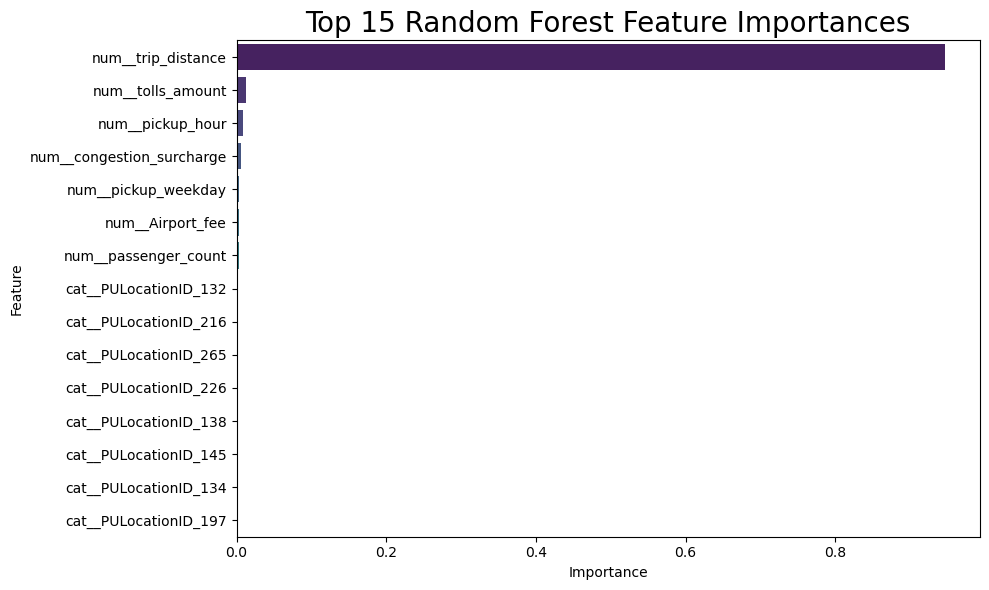

In [17]:
# Extract feature importances
importances = rf_pipeline.named_steps["model"].feature_importances_

# Get transformed feature names
feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

# Create dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort
importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

# Top 15
top_features = importance_df.head(15)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Top 15 Random Forest Feature Importances", fontsize=20)
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()